# Portfolio walkthrough

A visual tour of the published results of this study.

**This notebook reads committed summary files and nothing else.** It downloads no
data, reads no market snapshot, reads no source text, trains no model and re-runs no
part of P1. Every figure below is a rendering of numbers that are already in
`results/`, and the charts it writes to `reports/figures/` are pictures of the
committed record rather than new experiments.

The narrative versions live in `reports/`; the method is in
`docs/research_protocol.md`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repository whether this runs from the root or from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "results").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "results").is_dir(), "run this from the repository or from notebooks/"

FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Every number below is read from a committed summary file. Nothing is refitted,
# nothing is downloaded, and no market data is touched.
tests = pd.read_csv(ROOT / "results" / "statistical_tests.csv",
                    header=None, index_col=0).squeeze("columns")
stability = pd.read_csv(ROOT / "results" / "feature_stability.csv")
selection = pd.read_csv(ROOT / "results" / "selection_log.csv")
benchmarks = pd.read_csv(ROOT / "results" / "benchmark_intervals.csv")

INK, MUTED, RULE = "#1c1c1c", "#6f6f6f", "#d8d8d8"
NEG, POS, ZERO = "#b4442e", "#2f6f5f", "#8a8a8a"

plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 140, "savefig.bbox": "tight",
    "font.size": 9, "axes.edgecolor": RULE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

f"{int(tests['oos_sessions'])} out-of-sample sessions"


'1865 out-of-sample sessions'

## 1. The confirmatory result

Two conditions were pre-registered, both to be judged on a paired stationary
bootstrap fixed before the run.

**Condition A** — does the strategy beat always-long on Sharpe?
**Condition B** — does it beat cash on annualised mean return?

Neither passes. Both intervals contain zero, and so does the mean-return difference
against always-long — which is a *different* quantity from Condition A and carries
its own interval.


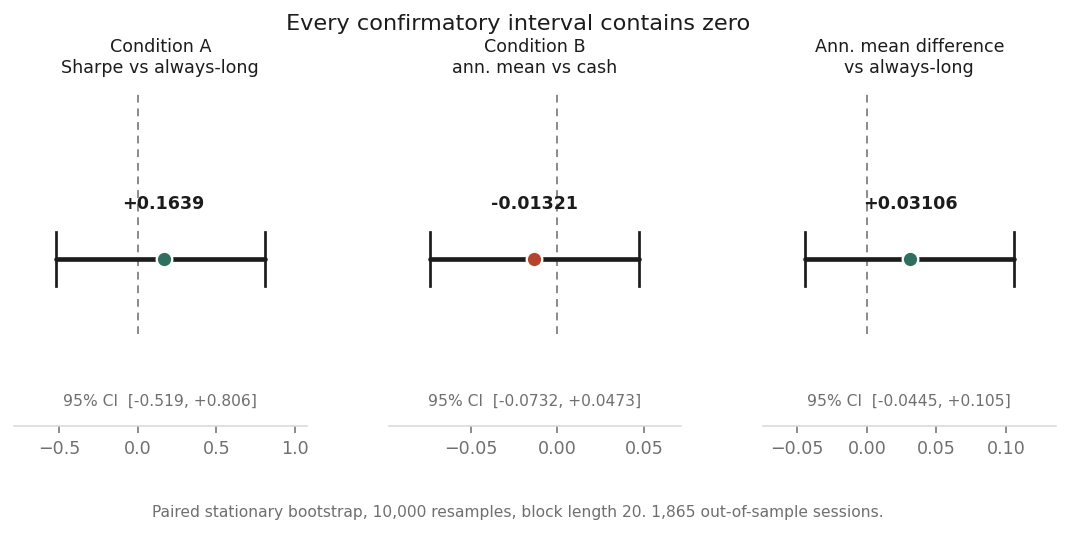

In [2]:
# Condition A tests a Sharpe difference; Condition B an annualised mean difference.
# The third row is the mean-return difference against always-long, which has its own
# interval and is not Condition A's.
rows = [
    ("Condition A\nSharpe vs always-long",
     float(tests["condition_a_d_sharpe"]),
     float(tests["condition_a_ci_low"]), float(tests["condition_a_ci_high"])),
    ("Condition B\nann. mean vs cash",
     float(tests["condition_b_d_annmean"]),
     float(tests["condition_b_ci_low"]), float(tests["condition_b_ci_high"])),
    ("Ann. mean difference\nvs always-long",
     float(tests["ann_mean_diff_vs_always_long"]),
     float(tests["ann_mean_diff_ci_low"]), float(tests["ann_mean_diff_ci_high"])),
]

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.1))
for ax, (label, point, lo, hi) in zip(axes, rows):
    # a segment, not a full-height line, so it does not run through the caption
    ax.plot([0, 0], [-0.45, 1.0], color=ZERO, lw=1, ls=(0, (4, 3)), zorder=1)
    ax.plot([lo, hi], [0, 0], color=INK, lw=2.4, solid_capstyle="round", zorder=2)
    for x in (lo, hi):
        ax.plot([x, x], [-0.16, 0.16], color=INK, lw=1.4, zorder=2)
    ax.plot([point], [0], "o", ms=8, color=NEG if point < 0 else POS,
            markeredgecolor="white", markeredgewidth=1.2, zorder=3)
    ax.set_title(label, fontsize=9, pad=10)
    ax.set_ylim(-1.0, 1.0)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    span = hi - lo
    ax.set_xlim(lo - 0.20 * span, hi + 0.20 * span)
    ax.annotate(f"{point:+.4g}", (point, 0.30), ha="center", fontsize=9,
                color=INK, fontweight="bold")
    ax.annotate(f"95% CI  [{lo:+.3g}, {hi:+.3g}]", (0.5, 0.06),
                xycoords="axes fraction", ha="center", fontsize=8, color=MUTED)

fig.subplots_adjust(wspace=0.28)
fig.suptitle("Every confirmatory interval contains zero", fontsize=11.5, y=1.06)
fig.text(0.5, -0.10,
         "Paired stationary bootstrap, 10,000 resamples, block length 20. "
         f"{int(tests['oos_sessions']):,} out-of-sample sessions.",
         ha="center", fontsize=8, color=MUTED)
fig.savefig(FIGURES / "confirmatory_intervals.png")
plt.show()


## 2. Where the return actually came from

The strategy's annualised mean return is **+3.11% above always-long**, which sounds
like a result until it is decomposed.

The directional timing contribution — what the predictions themselves are worth — is
**negative**. The positive total is the cost and financing saved by staying flat on
two thirds of sessions.

Holding no position is not a forecast. A strategy that trades less will save costs
whether or not it can predict anything, so this decomposition is the difference
between "the model works" and "the model mostly abstains".


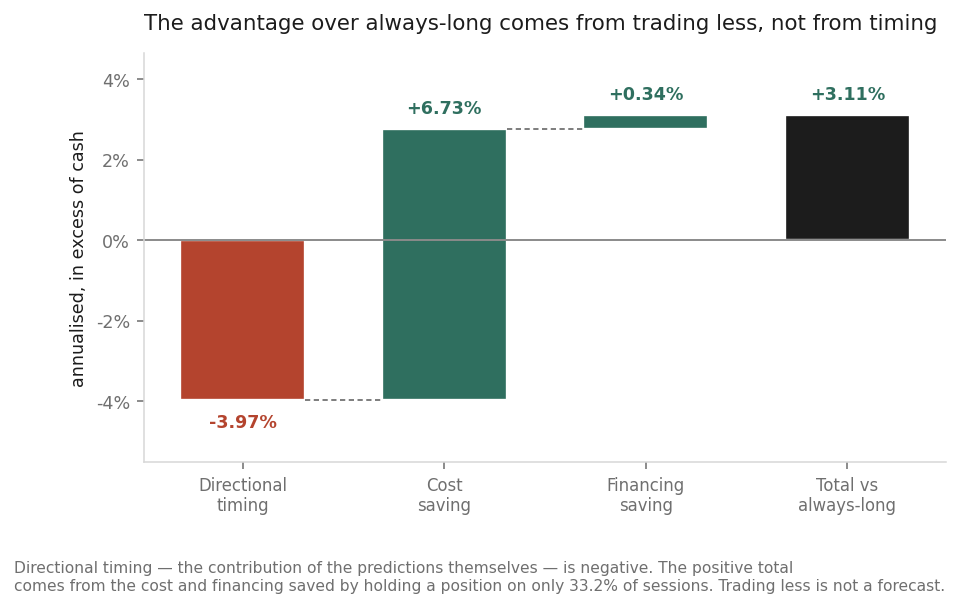

In [3]:
# The +3.11% advantage over always-long, decomposed into where it came from.
timing = float(tests["ann_gross_timing"])
cost = float(tests["ann_cost_saving"])
financing = float(tests["ann_financing_saving"])
total = float(tests["ann_mean_diff_vs_always_long"])
assert abs((timing + cost + financing) - total) < 1e-9

labels = ["Directional\ntiming", "Cost\nsaving", "Financing\nsaving", "Total vs\nalways-long"]
values = [timing, cost, financing, total]

fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axhline(0, color=ZERO, lw=1)

# Pad from the actual trajectory, so the deepest bar and its label both fit.
levels = np.cumsum([0, timing, cost, financing])
lo_y, hi_y = min(levels.min(), 0.0), max(levels.max(), total)
pad = 0.22 * (hi_y - lo_y)
ax.set_ylim(lo_y - pad, hi_y + pad)

running = 0.0
for i, (label, v) in enumerate(zip(labels, values)):
    if i < 3:
        ax.bar(i, v, bottom=running, width=0.62,
               color=POS if v > 0 else NEG, edgecolor="white", linewidth=1.2)
        if i:
            ax.plot([i - 0.69, i - 0.31], [running, running], color=MUTED, lw=0.9,
                    ls=(0, (3, 2)))
        running += v
    else:
        ax.bar(i, v, width=0.62, color=INK, edgecolor="white", linewidth=1.2)
    y = (running if i < 3 else v)
    ax.annotate(f"{v:+.2%}", (i, y), ha="center",
                va="bottom" if v > 0 else "top",
                xytext=(0, 6 if v > 0 else -7), textcoords="offset points",
                fontsize=9, fontweight="bold",
                color=POS if v > 0 else NEG if i < 3 else INK)

ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("annualised, in excess of cash")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("The advantage over always-long comes from trading less, not from timing",
             fontsize=11, pad=12, loc="left")
fig.text(0.0, -0.13,
         "Directional timing — the contribution of the predictions themselves — is "
         "negative. The positive total\ncomes from the cost and financing saved by "
         "holding a position on only "
         f"{float(tests['participation_rate']):.1%} of sessions. Trading less is not "
         "a forecast.",
         ha="left", fontsize=8, color=MUTED)
fig.savefig(FIGURES / "return_decomposition.png")
plt.show()


## 3. Model and feature selection

The selection machinery was stable: a handful of features survived the screen at
nearly every outer step, and the model family changed rarely.

**This is not evidence that the features are informative.** A screen that
consistently ranks the same uninformative variables highest produces exactly this
picture. Stability tells you the procedure is well-behaved, not that it found
anything — the point is recorded as A5 in `docs/errata.md` because an earlier draft
of the write-up got it wrong.


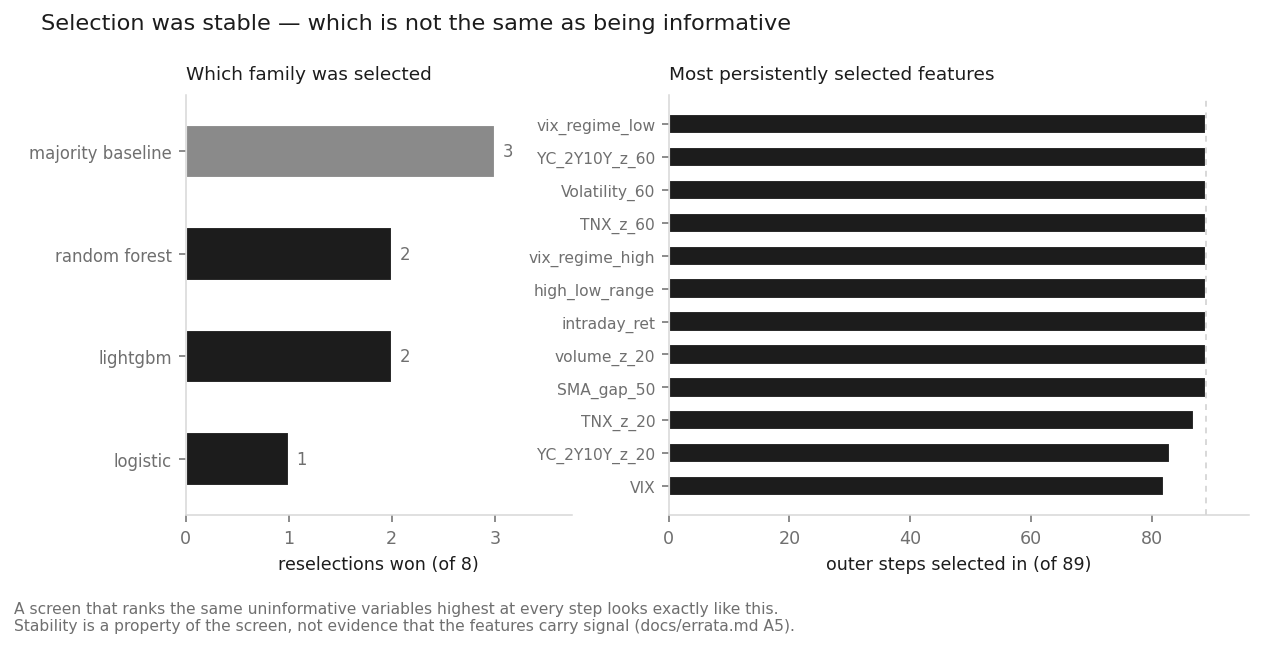

In [4]:
# Left: which model family won each reselection. Right: how often each feature
# survived the per-step screen.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.8, 3.9),
                               gridspec_kw={"width_ratios": [1, 1.5]})

families = selection.chosen_id.str.split("|").str[0].value_counts()
colours = {"majority_baseline": ZERO}
bars = ax1.barh(range(len(families)), families.values,
                color=[colours.get(n, INK) for n in families.index],
                height=0.52, edgecolor="white", linewidth=1.1)
ax1.set_yticks(range(len(families)))
ax1.set_yticklabels([n.replace("_", " ") for n in families.index], fontsize=8.5)
ax1.invert_yaxis()
ax1.set_xlabel(f"reselections won (of {len(selection)})")
ax1.set_title("Which family was selected", fontsize=9.5, loc="left", pad=8)
for i, v in enumerate(families.values):
    ax1.annotate(str(v), (v, i), xytext=(4, 0), textcoords="offset points",
                 va="center", fontsize=8.5, color=MUTED)
ax1.set_xlim(0, families.max() * 1.25)
ax1.set_ylim(len(families) - 0.45, -0.55)

top = stability.nlargest(12, "steps_selected").iloc[::-1]
total_steps = int(stability.steps_selected.max())
ax2.barh(range(len(top)), top.steps_selected, color=INK, height=0.62,
         edgecolor="white", linewidth=1.1)
ax2.set_yticks(range(len(top)))
ax2.set_yticklabels(top.feature, fontsize=8)
ax2.set_xlabel(f"outer steps selected in (of {total_steps})")
ax2.set_title("Most persistently selected features", fontsize=9.5, loc="left", pad=8)
ax2.set_xlim(0, total_steps * 1.08)
ax2.axvline(total_steps, color=RULE, lw=1, ls=(0, (3, 3)))

fig.suptitle("Selection was stable — which is not the same as being informative",
             fontsize=11.5, y=1.03, x=0.02, ha="left")
fig.text(0.0, -0.10,
         "A screen that ranks the same uninformative variables highest at every step "
         "looks exactly like this.\nStability is a property of the screen, not "
         "evidence that the features carry signal (docs/errata.md A5).",
         ha="left", fontsize=8, color=MUTED)
fig.savefig(FIGURES / "model_feature_stability.png")
plt.show()


## What this study concludes

**No stable, confirmable out-of-sample incremental value was found.** The
pre-registered verdict recorded in `results/statistical_tests.csv` is *insufficient
evidence of a stable incremental value*, and every confirmatory interval contains
zero.

The positive point estimate against always-long comes from the costs and financing
avoided by trading on a minority of sessions, not from the predictions. This is a
negative result about the strategy hypothesis, and it is not a deployable trading
system.

What the repository is for is the procedure that produced that answer: a
pre-registered protocol frozen and hashed before the run, nested walk-forward
validation with every data-dependent step inside the training folds, cost-aware
position sizing, and a complete exploratory group reported in full — including the
specifications that looked better than the confirmatory one.

| | |
|---|---|
| Method | [`docs/research_protocol.md`](../docs/research_protocol.md) |
| Confirmatory report | [`reports/p1_confirmatory_result.md`](../reports/p1_confirmatory_result.md) |
| Exploratory group | [`reports/exploratory_results.md`](../reports/exploratory_results.md) |
| Every trial ever run | [`results/experiment_registry.csv`](../results/experiment_registry.csv) |
| Corrections | [`docs/errata.md`](../docs/errata.md) |
